In [29]:
import os.path
from copy import deepcopy
import pickle as pkl
from typing import Callable
import numpy as np
from matplotlib import pyplot as plt
from qutip import QobjEvo, SESolver, expect, MESolver
from qutip.core import destroy, identity, tensor, Qobj, ket
from scipy.interpolate import interp1d, CubicSpline
from scipy.optimize import minimize
import pandas as pd
from scipy.linalg import sqrtm

from rlquantopt.rl_envs.zcqubits import ZCQubits
from rlquantopt.utils.rl_utils import get_pulse_data
from weylchamber import c1c2c3, concurrence


In [19]:
T = 50  # ns
pulse_length = 1000
model_params = dict()
model_params["omega_s"] = model_params.get("omega_s", [5.0311, 5.8899])
model_params["alpha_s"] = model_params.get("alpha_s", [-324e-3, -235e-3])
model_params["g"] = model_params.get("g", [100e-3, 71.4e-3])
model_params["alpha_c"] = model_params.get("alpha_c", -230e-3)
model_params["omega_r"] = model_params.get("omega_r", 6.0)
model_params["omega_c_0"] = model_params.get("omega_c_0", 7.445)
model_params["n_levels"] = n_levels = model_params.get("n_levels", 3)
model_params["num_qubits"] = num_qubits = model_params.get("num_qubits", 2)
model_params["coupler_dims"] = model_params.get("coupler_dims", 3)
model_params["qubit_dims"] = [n_levels] * num_qubits

In [55]:
pulse_path = '/home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO/05-12-24_201634/results/no_term/rl_model_12566528_steps_ZCQPEE_pl-1000_T-50ns_delta_mode_ep0_no_term.csv'
tlist, pulse = get_pulse_data(pulse_path)

['Unnamed: 0', 'amplist', 'tlist']


# SESolver

In [43]:
# Set up initial states
full_dims = model_params.get("qubit_dims").copy()
full_dims.append(model_params.get("coupler_dims"))
psi00 = ket((0, 0, 0), dim=full_dims)
psi01 = ket((0, 1, 0), dim=full_dims)
psi10 = ket((1, 0, 0), dim=full_dims)
psi11 = ket((1, 1, 0), dim=full_dims)
basis_states_ket = [psi00, psi01, psi10, psi11]
basis_states = basis_states_ket.copy()
initial_states = basis_states.copy()

# Set up SE solvers
# options = dict(method='adams')#, atol=1e-10, rtol=1e-8, order=5)
options = dict(method='adams', atol=1e-10, rtol=1e-8)

simulator = ZCQubits(**model_params)

solvers = [SESolver(simulator.H, options=options) for _ in range(len(basis_states))]
# solvers = [MESolver(simulator.H, options=options) for _ in range(len(basis_states))]

basis_states_str = ('$|000\\rangle$', '$|010\\rangle$','$|100\\rangle$','$|110\\rangle$',)
tlist = np.linspace(0, T, pulse_length + 1)

In [45]:
for k, initial_state in enumerate(basis_states):
    solvers[k].start(initial_state, 0.)

all_states = []
for i, (t, amp) in enumerate(zip(tlist, pulse)):
    final_states = []
    for k, _ in enumerate(basis_states):
        final_state = solvers[k].step(t, args=dict(A=amp))
        final_states.append(final_state)
    all_states.append(final_states.copy())
all_states = np.array(all_states)
all_states.shape

(1000, 4)

In [46]:
all_states[0]

array([Quantum object: dims=[[3, 3, 3], [1, 1, 1]], shape=(27, 1), type='ket', dtype=Dense
       Qobj data =
       [[1.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]]                                                                             ,
       Quantum object: dims=[[3, 3, 3], [1, 1, 1]], shape=(27, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.]
        [0.]
        [0.]
        [1.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]

In [53]:
n_states = len(basis_states)

cs = []
us = []
for h, step_states in enumerate(all_states):
    realised_gate = np.zeros(shape=(n_states, n_states), dtype=np.complex128)
    for i, s in enumerate(step_states):
        for j, b in enumerate(basis_states):
                realised_gate[i,j] = s.overlap(b)
    realised_gate = Qobj(realised_gate, dims=([[2,2], [2,2]]))
    # print(realised_gate)
    # break

    c = concurrence(*c1c2c3(realised_gate))
    u = (realised_gate.dag() * realised_gate).tr() / 4

    cs.append(c)
    us.append(u)
    print(f'{h}: C={c:.4f}, U={u:.4f}')
cs = np.array(cs)
us = np.array(us)

0: C=0.0000, U=1.0000
1: C=0.0001, U=0.9993
2: C=0.0010, U=0.9974
3: C=0.0031, U=0.9951
4: C=0.0055, U=0.9918
5: C=0.0078, U=0.9873
6: C=0.0112, U=0.9824
7: C=0.0160, U=0.9778
8: C=0.0222, U=0.9740
9: C=0.0297, U=0.9727
10: C=0.0372, U=0.9721
11: C=0.0447, U=0.9706
12: C=0.0518, U=0.9688
13: C=0.0566, U=0.9679
14: C=0.0546, U=0.9699
15: C=0.0460, U=0.9732
16: C=0.0427, U=0.9753
17: C=0.0465, U=0.9755
18: C=0.0500, U=0.9740
19: C=0.0500, U=0.9712
20: C=0.0443, U=0.9682
21: C=0.0370, U=0.9671
22: C=0.0366, U=0.9670
23: C=0.0416, U=0.9666
24: C=0.0494, U=0.9663
25: C=0.0586, U=0.9658
26: C=0.0683, U=0.9659
27: C=0.0778, U=0.9675
28: C=0.0869, U=0.9691
29: C=0.0957, U=0.9699
30: C=0.1037, U=0.9713
31: C=0.1111, U=0.9722
32: C=0.1179, U=0.9718
33: C=0.1241, U=0.9711
34: C=0.1293, U=0.9711
35: C=0.1323, U=0.9735
36: C=0.1318, U=0.9776
37: C=0.1280, U=0.9814
38: C=0.1250, U=0.9822
39: C=0.1264, U=0.9803
40: C=0.1276, U=0.9785
41: C=0.1261, U=0.9769
42: C=0.1218, U=0.9754
43: C=0.1165, U=0.973

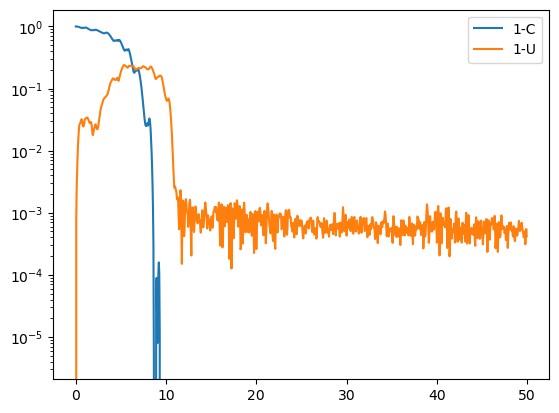

In [54]:
plt.plot(tlist, 1-cs, label='1-C')
plt.plot(tlist, 1-us, label='1-U')
plt.yscale('log')
plt.legend(loc='best')
plt.show()

# MESolver

In [56]:
# Set up initial states
full_dims = model_params.get("qubit_dims").copy()
full_dims.append(model_params.get("coupler_dims"))
psi00 = ket((0, 0, 0), dim=full_dims)
psi01 = ket((0, 1, 0), dim=full_dims)
psi10 = ket((1, 0, 0), dim=full_dims)
psi11 = ket((1, 1, 0), dim=full_dims)
basis_states_ket = [psi00, psi01, psi10, psi11]
basis_states = basis_states_ket.copy()
initial_states = basis_states.copy()

# Set up SE solvers
# options = dict(method='adams')#, atol=1e-10, rtol=1e-8, order=5)
options = dict(method='adams', atol=1e-10, rtol=1e-8)

simulator = ZCQubits(**model_params)

solvers = [MESolver(simulator.H, options=options) for _ in range(len(basis_states))]
# solvers = [MESolver(simulator.H, options=options) for _ in range(len(basis_states))]

basis_states_str = ('$|000\\rangle$', '$|010\\rangle$','$|100\\rangle$','$|110\\rangle$',)
tlist = np.linspace(0, T, pulse_length + 1)

In [57]:
for k, initial_state in enumerate(basis_states):
    solvers[k].start(initial_state, 0.)

all_states = []
for i, (t, amp) in enumerate(zip(tlist, pulse)):
    final_states = []
    for k, _ in enumerate(basis_states):
        final_state = solvers[k].step(t, args=dict(A=amp))
        final_states.append(final_state)
    all_states.append(final_states.copy())
all_states = np.array(all_states)
all_states.shape

(1000, 4)

In [63]:
np.sqrt(all_states[-1][0].diag())

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
n_states = len(basis_states)

cs = []
us = []
for h, step_states in enumerate(all_states):
    realised_gate = np.zeros(shape=(n_states, n_states), dtype=np.complex128)
    for i, s in enumerate(step_states):
        for j, b in enumerate(basis_states):
                realised_gate[i,j] = s.overlap(b)
    realised_gate = Qobj(realised_gate, dims=([[2,2], [2,2]]))
    # print(realised_gate)
    # break

    c = concurrence(*c1c2c3(realised_gate))
    u = (realised_gate.dag() * realised_gate).tr() / 4

    cs.append(c)
    us.append(u)
    print(f'{h}: C={c:.4f}, U={u:.4f}')
cs = np.array(cs)
us = np.array(us)

In [ ]:
plt.plot(tlist, 1-cs, label='1-C')
plt.plot(tlist, 1-us, label='1-U')
plt.yscale('log')
plt.legend(loc='best')
plt.show()